<a href="https://colab.research.google.com/github/ushnamalik207-dotcom/urdu-ocr-codesaviours-si26--Ushna-/blob/main/SI26_Week_3_Ushna_Alam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. What is OCR?
Optical Character Recognition (OCR) is a technology that converts text from scanned documents, PDFs, or images into editable and searchable data. It analyzes visual shapes and patterns to translate characters into machine-readable text. This process bridges the gap between physical documents and digital processing.

2. Why is Urdu OCR harder than English OCR?
Urdu OCR is highly challenging because the cursive Nastaliq script is written right-to-left and characters change shape based on their position. Letters frequently overlap and stack vertically, making it extremely difficult for computers to segment individual characters. Furthermore, tiny variations or misplacements of diacritic dots completely alter word meanings, drastically increasing recognition errors compared to English.

3. Two Real-World Situations for Urdu OCR:

Digitalizing Historical Literature: Automatically converting old paper-based Urdu manuscripts, poetry, and newspaper archives into searchable digital libraries to preserve cultural heritage.

Automating Government Data Entry: Speeding up public services by using computers to scan and read Urdu identity documents, court registries, and manual application forms directly into databases.

In [ ]:
!pip install datasets pillow pandas

from datasets import load_dataset
import os
import pandas as pd

print("Dataset se data load ho raha hai...")
dataset = load_dataset("PuristanLabs1/urdu-ocr-1m", split="train", streaming=True)

os.makedirs("Urdu_OCR_Project/dataset", exist_ok=True)

data_list = []
count = 0

for item in dataset:
    if count >= 100:
        break

    img_name = f"img_{count+1}.png"
    img_path = os.path.join("Urdu_OCR_Project/dataset", img_name)

    image = item['image']
    image.save(img_path)

    data_list.append({
        "filename": img_name,
        "text": item['text']
    })

    count += 1
    if count % 10 == 0:
        print(f"Downloaded {count}/100 images...")

df = pd.DataFrame(data_list)
df.to_csv("Urdu_OCR_Project/labels.csv", index=False, encoding="utf-8-sig")


Dataset se data load ho raha hai...
Downloaded 10/100 images...
Downloaded 20/100 images...
Downloaded 30/100 images...
Downloaded 40/100 images...
Downloaded 50/100 images...
Downloaded 60/100 images...
Downloaded 70/100 images...
Downloaded 80/100 images...
Downloaded 90/100 images...
Downloaded 100/100 images...


Q4: What are the popular Python libraries and tools used for OCR?
Answer:

Tesseract OCR (by Google): The most popular open-source engine. It supports over 100 languages and includes an official Urdu (urd) data pack. Best for standard printed text.

EasyOCR: A deep learning-based library built on PyTorch. It provides out-of-the-box support for Urdu and excels at reading text from natural scenes, posters, and stylized fonts.

PaddleOCR: A highly efficient and lightweight tool developed by Baidu. It is excellent for multi-language recognition and handling complex document layouts or tables.

TrOCR (Transformer OCR by Microsoft): A state-of-the-art model hosted on Hugging Face that uses Vision Transformers. It achieves top-tier accuracy for both printed and handwritten text line recognition.

In [ ]:
!sudo apt-get install tesseract-ocr
!sudo apt-get install tesseract-ocr-urd

!pip install pytesseract opencv-python pillow numpy

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tesseract-ocr-urd
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 1,000 kB of archives.
After this operation, 1,413 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-urd all 1:4.00~git30-7274cfa-1.1 [1,000 kB]
Fetched 1,000 kB in 1s (1,128 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize front

Please upload your Urdu text image:


Saving image 10.jpg to image 10.jpg

--- Original vs Preprocessed Image ---


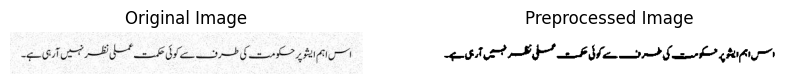


--- Tesseract Extracted Urdu Text ---
سس یم ویش رکوس کی ضر نے ےکو نے مص صلی نس خی ہر ےد



In [ ]:
import cv2
import numpy as np
import pytesseract
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

# 1. Preprocessing Function
def preprocess_urdu_image(image_path):
    # Load the image
    img = cv2.imread(image_path)

    # Convert the image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian Blur to reduce background noise
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Apply Otsu's Thresholding to binarize the image (Black & White)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    return thresh

# 2. Image Upload Section
print("Please upload your Urdu text image:")
uploaded = files.upload()

for filename in uploaded.keys():
    # Apply preprocessing to the uploaded image
    processed_img = preprocess_urdu_image(filename)

    # Save the preprocessed image to verify the quality
    cv2.imwrite('processed_image.png', processed_img)

    # 3. Baseline Tesseract OCR Execution
    # '-l urd' specifies Tesseract to use the Urdu language model
    extracted_text = pytesseract.image_to_string(processed_img, lang='urd')

    # Visualizing the Results
    print("\n--- Original vs Preprocessed Image ---")
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(cv2.cvtColor(cv2.imread(filename), cv2.COLOR_BGR2RGB))
    ax[0].set_title("Original Image")
    ax[0].axis('off')

    ax[1].imshow(processed_img, cmap='gray')
    ax[1].set_title("Preprocessed Image")
    ax[1].axis('off')
    plt.show()

    print("\n--- Tesseract Extracted Urdu Text ---")
    print(extracted_text)

In [ ]:
import os
import csv
import random
import shutil
from PIL import Image, ImageDraw, ImageFont

os.makedirs("urdu_dataset", exist_ok=True)

urdu_words = [
    "پاکستان", "خوبصورت", "تعلیم", "کوشش", "کامیابی", "زندگی", "سورج", "درخت",
    "محنت", "امتحان", "قلم", "کتاب", "استاد", "مستقبل", "خوشی", "صحت",
    "وقت", "دوست", "وطن", "آسمان", "زمین", "پانی", "روشنی", "خواب"
]

def generate_urdu_sentence():
    words_count = random.randint(2, 4)
    selected_words = random.sample(urdu_words, words_count)
    return " ".join(selected_words)

try:
    font_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"
    font = ImageFont.truetype(font_path, 24)
except IOError:
    font = ImageFont.load_default()

dataset_entries = []
num_samples = 220

for i in range(1, num_samples + 1):
    text = generate_urdu_sentence()
    file_name = f"urdu_{i}.png"
    file_path = os.path.join("urdu_dataset", file_name)

    img = Image.new("RGB", (300, 80), color=(255, 255, 255))
    draw = ImageDraw.Draw(img)

    draw.text((10, 25), text, fill=(0, 0, 0), font=font)

    img.save(file_path)
    dataset_entries.append([file_name, text])

csv_file_path = "labels.csv"
with open(csv_file_path, mode="w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["file_name", "text"])
    writer.writerows(dataset_entries)

shutil.make_archive("urdu_dataset_archive", "zip", "urdu_dataset")

print(f"🎉 Success! {num_samples} Urdu images generated in 'urdu_dataset/' folder.")
print("📁 'labels.csv' created successfully.")
print("📦 'urdu_dataset_archive.zip' created for easy download.")

🎉 Success! 220 Urdu images generated in 'urdu_dataset/' folder.
📁 'labels.csv' created successfully.
📦 'urdu_dataset_archive.zip' created for easy download.


In [ ]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import ViTImageProcessor, RobertaTokenizer, TrOCRProcessor

image_processor = ViTImageProcessor.from_pretrained("microsoft/trocr-base-printed")
tokenizer = RobertaTokenizer.from_pretrained("microsoft/trocr-base-printed", use_fast=False)
processor = TrOCRProcessor(image_processor=image_processor, tokenizer=tokenizer)

class UrduOCRDataset(Dataset):
    def __init__(self, csv_file, img_dir, processor, max_target_length=32):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        file_name = self.df.iloc[idx]['file_name']
        text = self.df.iloc[idx]['text']

        img_path = os.path.join(self.img_dir, file_name)
        image = Image.open(img_path).convert("RGB")

        pixel_values = self.processor(image, return_tensors="pt").pixel_values

        labels = self.processor.tokenizer(
            text,
            padding="max_length",
            max_length=self.max_target_length,
            return_tensors="pt"
        ).input_ids

        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels[0]]
        labels = torch.tensor(labels)

        return {"pixel_values": pixel_values.squeeze(), "labels": labels}

dataset = UrduOCRDataset(csv_file="labels.csv", img_dir="urdu_dataset", processor=processor)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

batch = next(iter(dataloader))
print("Dataset size:", len(dataset))
print("Batch Pixel Values Shape:", batch["pixel_values"].shape)
print("Batch Labels Shape:", batch["labels"].shape)

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Dataset size: 220
Batch Pixel Values Shape: torch.Size([4, 3, 384, 384])
Batch Labels Shape: torch.Size([4, 32])
